# AICE Associate 대비 실습 과정 — 2회차
## 데이터 구조 확인하기, 기초 데이터 다루기

> **과정 구성**: 총 8회 × 3시간, 실습 위주  
> **선수 학습**: 1회차 (데이터 획득). 1회차에서 만든 `data/customers.csv`, `data/sales_2024.csv`, `data/customers.xlsx` 를 사용합니다.

### 전체 커리큘럼

| 회차 | 주제 | 핵심 키워드 |
|:---:|------|------------|
| 1 | AI/ML/DL 개요, 데이터 획득하기 | AI ⊃ ML ⊃ DL, 지도/비지도, `read_csv`, `read_excel`, `to_csv` |
| **2** | **데이터 구조 확인하기, 기초 데이터 다루기** | `info`, `describe`, `loc/iloc`, 필터링, 정렬, `groupby`, `merge` |
| 3 | 데이터 이해하기 (EDA) | 분포, 상관관계, `matplotlib`, `seaborn`, 가설 검증 |
| 4 | 데이터 전처리하기 | 결측치, 이상치, 구간화, 인코딩, 스케일링, `train_test_split` |
| 5 | AI 모델링 필수 개념, 지도학습 I | 과적합, 평가지표, 선형회귀, 로지스틱 회귀 |
| 6 | 지도학습 II | 의사결정나무, 앙상블, 랜덤포레스트, 그라디언트부스팅 |
| 7 | 인공신경망, 심층신경망, 딥러닝 프레임워크 | 퍼셉트론, 활성화함수, Keras `Sequential`, `EarlyStopping` |
| 8 | 비지도학습, 모델 성능 향상시키기 | K-Means, PCA, 교차검증, 하이퍼파라미터 튜닝, 모의고사 |

### 오늘의 학습 목표

1. `head`, `info`, `describe`, `value_counts` 로 처음 보는 데이터의 **크기·자료형·결측·분포** 를 5분 안에 파악할 수 있다.
2. `loc` 와 `iloc` 의 차이를 설명하고, 행·열을 자유롭게 선택할 수 있다.
3. 조건식(`&`, `|`, `~`, `isin`, `between`, `str.contains`)으로 원하는 행만 골라낼 수 있다.
4. 컬럼을 추가·수정·삭제·이름변경하고, `apply`/`map`/`np.where` 로 파생 변수를 만들 수 있다.
5. `groupby`, `pivot_table` 로 그룹별 통계를 내고, `merge`/`concat` 으로 데이터를 결합할 수 있다.
6. 날짜형 컬럼에서 연·월·요일을 추출해 시간 단위로 집계할 수 있다.

### 시간 계획 (180분)

| 시간 | 내용 |
|------|------|
| 00:00 ~ 00:10 | 0. 환경 준비, 데이터 불러오기 |
| 00:10 ~ 01:00 | 1. 데이터 구조 확인하기 |
| 01:00 ~ 01:10 | 휴식 |
| 01:10 ~ 02:30 | 2. 기초 데이터 다루기 |
| 02:30 ~ 02:40 | 휴식 |
| 02:40 ~ 03:00 | 3. 종합 실습 + 정리 |

---
## 0. 환경 준비, 데이터 불러오기

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 옵션: 컬럼이 많아도 생략하지 않고, 소수점은 2자리까지
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = "data"
print("pandas", pd.__version__)

pandas 2.2.1


In [2]:
# 한글 폰트 설정 (1회차와 동일). Colab 은 나눔폰트 설치 후 런타임 재시작 필요.
#   !apt-get -qq install fonts-nanum
#   !rm -rf ~/.cache/matplotlib
from matplotlib import font_manager


def set_korean_font() -> str:
  candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]
  installed = {f.name for f in font_manager.fontManager.ttflist}
  for name in candidates:
    if name in installed:
      plt.rcParams["font.family"] = name
      plt.rcParams["axes.unicode_minus"] = False
      return name
  plt.rcParams["axes.unicode_minus"] = False
  return "(한글 폰트 없음 - 그래프의 한글이 깨질 수 있음)"


print("적용된 폰트:", set_korean_font())

적용된 폰트: AppleGothic


1회차에서 만든 파일이 없다면 아래 셀이 **동일한 데이터를 다시 생성** 합니다. (1회차와 같은 seed 를 쓰므로 내용이 같습니다.)

In [3]:
# ===== 1회차 실습 데이터가 없을 때만 재생성 (실행만 하면 됩니다) =====
def ensure_session1_data(data_dir: str = DATA_DIR) -> None:
  required = ["customers.csv", "customers.xlsx", "sales_2024.csv"]
  if all(os.path.exists(f"{data_dir}/{f}") for f in required):
    print("1회차 데이터 확인 완료:", required)
    return

  os.makedirs(data_dir, exist_ok=True)
  rng = np.random.default_rng(42)
  n = 300
  regions = ["서울", "경기", "부산", "대구", "기타"]
  plans = ["5G", "LTE", "3G"]

  # 데이터 사용량: 일반 사용자(90%)는 평균 12GB·표준편차 4GB 의 종 모양(정규분포)으로,
  #               헤비 유저(10%)는 30~70GB 사이에서 고르게(균등분포) 만든다.
  #               -> 대부분은 10GB 안팎이고 소수만 큰 값을 가지는, 오른쪽 꼬리가 긴 분포가 된다.
  is_heavy = rng.random(n) < 0.10                                    # 행마다 10% 확률로 헤비 유저
  usage = np.where(is_heavy, rng.uniform(30, 70, size=n), rng.normal(12, 4, size=n))
  usage = np.clip(usage, 0.5, None)                                  # 음수 방지: 최소 0.5GB
  customers = pd.DataFrame({
    "고객ID": [f"C{i:04d}" for i in range(1, n + 1)],
    "성별": rng.choice(["M", "F"], size=n),
    "나이": rng.integers(19, 70, size=n).astype(float),
    "지역": rng.choice(regions, size=n, p=[0.35, 0.3, 0.15, 0.1, 0.1]),
    "우편번호": [f"{z:05d}" for z in rng.integers(1000, 63999, size=n)],
    "요금제": rng.choice(plans, size=n, p=[0.5, 0.4, 0.1]),
    "월요금": rng.choice([29000, 35000, 45000, 55000, 65000, 79000, 89000], size=n).astype(float),
    "데이터사용량": np.round(usage, 1),
    "가입일": pd.to_datetime("2019-01-01") + pd.to_timedelta(rng.integers(0, 2000, size=n), unit="D"),
  })
  customers["가입개월수"] = ((pd.to_datetime("2024-12-31") - customers["가입일"]).dt.days // 30)
  churn_prob = 0.15 + 0.25 * (customers["가입개월수"] < 12) + 0.1 * (customers["요금제"] == "3G")
  customers["이탈여부"] = np.where(rng.random(n) < churn_prob, "Yes", "No")
  customers.loc[rng.choice(n, 12, replace=False), "나이"] = np.nan
  customers.loc[rng.choice(n, 8, replace=False), "데이터사용량"] = np.nan
  customers.to_csv(f"{data_dir}/customers.csv", index=False)

  plan_info = pd.DataFrame({"요금제": plans, "속도Mbps": [1000, 150, 10], "출시연도": [2019, 2011, 2006]})
  with pd.ExcelWriter(f"{data_dir}/customers.xlsx") as writer:
    customers.to_excel(writer, sheet_name="customers", index=False)
    plan_info.to_excel(writer, sheet_name="plans", index=False)

  dates = pd.date_range("2024-01-01", "2024-12-31", freq="D")
  sales = pd.DataFrame({
    "날짜": np.repeat(dates, 3),
    "매장": np.tile(["강남점", "홍대점", "부산점"], len(dates)),
    "판매량": rng.poisson(20, size=len(dates) * 3),
  })
  sales["매출액"] = sales["판매량"] * rng.choice([12000, 15000, 18000], size=len(sales))
  sales.to_csv(f"{data_dir}/sales_2024.csv", index=False)
  print("1회차 데이터를 재생성했습니다:", required)


ensure_session1_data()

1회차 데이터 확인 완료: ['customers.csv', 'customers.xlsx', 'sales_2024.csv']


In [4]:
# 1회차에서 배운 옵션을 그대로 사용해 읽는다.
df = pd.read_csv(
  f"{DATA_DIR}/customers.csv",
  dtype={"우편번호": str},
  parse_dates=["가입일"],
)
sales = pd.read_csv(f"{DATA_DIR}/sales_2024.csv", parse_dates=["날짜"])
plans = pd.read_excel(f"{DATA_DIR}/customers.xlsx", sheet_name="plans")

print("customers:", df.shape, "| sales:", sales.shape, "| plans:", plans.shape)

customers: (300, 11) | sales: (1098, 4) | plans: (3, 3)


---
## 1. 데이터 구조 확인하기

### 한 줄 정의
모델링 전에 **"이 데이터가 몇 행 몇 열이고, 각 컬럼이 무슨 타입이며, 어디가 비어 있고, 값이 어떻게 분포하는지"** 를 파악하는 단계.

### 직관적 설명
병원에서 진료 전에 키·몸무게·혈압을 재는 것과 같습니다. 이 단계를 건너뛰면 "문자열 컬럼에 평균을 내려다 에러", "결측치 때문에 학습 실패" 같은 문제를 나중에 훨씬 비싸게 치릅니다.

#### 처음 보는 데이터를 만났을 때의 5단계 루틴

| 순서 | 질문 | 코드 |
|:---:|------|------|
| 1 | 어떻게 생겼나? | `df.head()`, `df.tail()`, `df.sample(5)` |
| 2 | 얼마나 크고 어떤 컬럼이 있나? | `df.shape`, `df.columns`, `df.dtypes` |
| 3 | 타입과 결측은? | `df.info()`, `df.isnull().sum()` |
| 4 | 숫자는 어떤 범위인가? | `df.describe()` |
| 5 | 범주는 어떤 값이 몇 개인가? | `df["col"].value_counts()`, `df["col"].nunique()` |

### 1.1 첫인상: `head` / `tail` / `sample` / `shape` / `columns`

In [5]:
df.head()        # 앞 5행 (괄호 안에 숫자를 넣으면 그만큼)

,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
0,C0001,M,46.00,경기,38671,5G,"29,000.00",17.00,2021-11-19,37,No
1,C0002,M,54.00,부산,47947,5G,"65,000.00",11.00,2019-11-22,62,No
2,C0003,M,58.00,대구,23029,LTE,"89,000.00",13.50,2019-08-12,65,No
3,C0004,F,67.00,경기,09262,LTE,"65,000.00",2.40,2021-11-04,38,No
4,C0005,M,48.00,경기,25370,5G,"55,000.00",NaN,2023-07-09,18,Yes


In [6]:
df.tail(3)       # 뒤 3행: 파일 끝에 합계 행이나 이상한 행이 붙어 있는지 확인

,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
297,C0298,M,43.00,부산,54339,LTE,"89,000.00",4.40,2023-05-07,20,Yes
298,C0299,F,50.00,경기,40817,5G,"55,000.00",4.20,2020-12-04,49,No
299,C0300,F,32.00,서울,26148,LTE,"45,000.00",12.00,2019-04-28,69,No


In [7]:
df.sample(5, random_state=1)   # 무작위 5행: 앞부분만 보고 착각하는 것을 방지

,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
189,C0190,M,26.00,경기,52311,5G,"79,000.00",NaN,2020-01-07,60,No
123,C0124,M,52.00,경기,26663,5G,"65,000.00",16.50,2021-04-15,45,No
185,C0186,M,63.00,대구,09823,5G,"29,000.00",15.00,2024-02-18,10,No
213,C0214,M,62.00,경기,14423,3G,"89,000.00",9.00,2019-06-25,67,No
106,C0107,M,39.00,부산,28786,5G,"55,000.00",9.90,2024-04-26,8,No


In [8]:
print("shape   :", df.shape)            # (행 수, 열 수) 튜플
print("행 수    :", df.shape[0], "=", len(df))
print("열 수    :", df.shape[1])
print("columns :", df.columns.tolist())  # 컬럼명 리스트 (복사해서 쓰기 편함)
print("index   :", df.index)            # 기본은 RangeIndex (0, 1, 2, ...)

shape   : (300, 11)
행 수    : 300 = 300
열 수    : 11
columns : ['고객ID', '성별', '나이', '지역', '우편번호', '요금제', '월요금', '데이터사용량', '가입일', '가입개월수', '이탈여부']
index   : RangeIndex(start=0, stop=300, step=1)


### 1.2 `info()`: 자료형과 결측을 한 번에

`info()` 출력을 읽는 법:

```
RangeIndex: 300 entries, 0 to 299      ← 전체 행 수 = 300
 #   Column         Non-Null Count  Dtype
 2   나이           288 non-null    float64   ← 300 - 288 = 12개 결측!
 8   가입일         300 non-null    datetime64[ns]
```

- **Non-Null Count 가 전체 행 수보다 작으면 결측치가 있다.**
- **Dtype 이 `object` 면 문자열(또는 섞인 타입)** 이다. 숫자여야 할 컬럼이 `object` 면 정제가 필요하다.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   고객ID    300 non-null    object        
 1   성별      300 non-null    object        
 2   나이      288 non-null    float64       
 3   지역      300 non-null    object        
 4   우편번호    300 non-null    object        
 5   요금제     300 non-null    object        
 6   월요금     300 non-null    float64       
 7   데이터사용량  292 non-null    float64       
 8   가입일     300 non-null    datetime64[ns]
 9   가입개월수   300 non-null    int64         
 10  이탈여부    300 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 25.9+ KB


In [10]:
# dtypes 만 따로: 타입별로 컬럼을 나눠 볼 때 유용
print(df.dtypes, "\n")

num_cols = df.select_dtypes(include="number").columns.tolist()
obj_cols = df.select_dtypes(include="object").columns.tolist()
print("숫자형 컬럼 :", num_cols)
print("문자형 컬럼 :", obj_cols)

고객ID              object
성별                object
나이               float64
지역                object
우편번호              object
요금제               object
월요금              float64
데이터사용량           float64
가입일       datetime64[ns]
가입개월수              int64
이탈여부              object
dtype: object 

숫자형 컬럼 : ['나이', '월요금', '데이터사용량', '가입개월수']
문자형 컬럼 : ['고객ID', '성별', '지역', '우편번호', '요금제', '이탈여부']


### 1.3 `describe()`: 숫자의 범위와 분포

| 통계량 | 의미 | 확인 포인트 |
|------|------|------|
| `count` | 결측 아닌 개수 | 행 수보다 작으면 결측 |
| `mean` / `50%` | 평균 / 중앙값 | 둘이 크게 다르면 **치우친 분포** 또는 이상치 |
| `std` | 표준편차 | 0 이면 값이 하나뿐 (쓸모없는 컬럼) |
| `min` / `max` | 최소 / 최대 | 나이 -1, 요금 0 처럼 **말이 안 되는 값** 찾기 |
| `25%` / `75%` | 사분위수 | 4회차 이상치(IQR) 계산에 사용 |

In [11]:
df.describe()          # 숫자형 컬럼만 (datetime 은 제외됨)

,나이,월요금,데이터사용량,가입일,가입개월수
count,288.00,300.00,292.00,300,300.00
mean,43.89,"55,273.33",15.13,2021-08-28 15:40:48,40.18
min,19.00,"29,000.00",1.30,2019-01-16 00:00:00,6.00
25%,32.00,"35,000.00",9.50,2020-06-05 18:00:00,22.00
50%,43.00,"55,000.00",12.45,2021-06-26 00:00:00,42.00
75%,57.00,"79,000.00",15.45,2023-02-22 00:00:00,55.00
max,69.00,"89,000.00",69.50,2024-06-22 00:00:00,72.00
std,14.62,"20,256.35",11.49,NaN,19.19


In [12]:
df.describe().T        # 전치(.T)하면 컬럼이 많을 때 읽기 쉽다

,count,mean,min,25%,50%,75%,max,std
나이,288.00,43.89,19.00,32.00,43.00,57.00,69.00,14.62
월요금,300.00,"55,273.33","29,000.00","35,000.00","55,000.00","79,000.00","89,000.00","20,256.35"
데이터사용량,292.00,15.13,1.30,9.50,12.45,15.45,69.50,11.49
가입일,300,2021-08-28 15:40:48,2019-01-16 00:00:00,2020-06-05 18:00:00,2021-06-26 00:00:00,2023-02-22 00:00:00,2024-06-22 00:00:00,NaN
가입개월수,300.00,40.18,6.00,22.00,42.00,55.00,72.00,19.19


In [13]:
# 문자형(범주형) 컬럼의 요약: 고유값 수, 최빈값, 최빈값 빈도
df.describe(include="object")

,고객ID,성별,지역,우편번호,요금제,이탈여부
count,300,300,300,300,300,300
unique,300,2,5,300,3,2
top,C0001,M,경기,38671,5G,No
freq,1,153,105,1,140,241


In [14]:
# 개별 통계량 직접 계산 (시험에서 "평균을 구하시오" 형태로 출제)
print("나이 평균   :", round(df["나이"].mean(), 2))
print("나이 중앙값 :", df["나이"].median())
print("나이 최대   :", df["나이"].max())
print("요금 표준편차:", round(df["월요금"].std(), 2))
print("사용량 90% 분위수:", df["데이터사용량"].quantile(0.9))
print("\n여러 컬럼 한 번에:")
print(df[["나이", "월요금", "데이터사용량"]].mean())

나이 평균   : 43.89
나이 중앙값 : 43.0
나이 최대   : 69.0
요금 표준편차: 20256.35
사용량 90% 분위수: 21.370000000000044

여러 컬럼 한 번에:
나이           43.89
월요금      55,273.33
데이터사용량       15.13
dtype: float64


### 1.4 `value_counts()`: 범주형 값의 분포

- 기본은 **빈도 내림차순**. `normalize=True` 면 비율.
- 결측치(NaN)는 기본으로 **세지 않는다**. 세려면 `dropna=False`.
- 분류 문제에서 **타깃(y)의 클래스 비율** 을 확인하는 데 반드시 씁니다. (불균형 데이터 판단)

In [15]:
print(df["요금제"].value_counts(), "\n")
print(df["요금제"].value_counts(normalize=True).round(3), "\n")   # 비율
print("고유값 목록:", df["지역"].unique())
print("고유값 개수:", df["지역"].nunique())

요금제
5G     140
LTE    124
3G      36
Name: count, dtype: int64 

요금제
5G    0.47
LTE   0.41
3G    0.12
Name: proportion, dtype: float64 

고유값 목록: ['경기' '부산' '대구' '서울' '기타']
고유값 개수: 5


In [16]:
# 타깃 클래스 비율 확인: 이탈(Yes) 이 약 20% -> 불균형 데이터 (5회차 평가지표 선택에 영향)
df["이탈여부"].value_counts(normalize=True)

이탈여부
No    0.80
Yes   0.20
Name: proportion, dtype: float64

In [17]:
# 숫자형 컬럼에도 쓸 수 있다. bins 로 구간 나눠 세기
df["나이"].value_counts(bins=5, sort=False)

(18.948999999999998, 29.0]    58
(29.0, 39.0]                  64
(39.0, 49.0]                  53
(49.0, 59.0]                  58
(59.0, 69.0]                  55
Name: count, dtype: int64

### 1.5 결측치 개수와 비율

4회차에서 처리 방법을 배우고, 오늘은 **얼마나 비어 있는지 세는 것** 까지만 합니다.

In [18]:
missing = df.isnull().sum()                     # 컬럼별 결측 개수 (isna() 와 동일)
missing_ratio = (df.isnull().mean() * 100).round(1)   # 비율(%) : mean() 은 True 의 비율

missing_table = pd.DataFrame({"결측수": missing, "결측비율(%)": missing_ratio})
missing_table[missing_table["결측수"] > 0]

,결측수,결측비율(%)
나이,12,4.00
데이터사용량,8,2.70


In [19]:
print("전체 결측치 수      :", df.isnull().sum().sum())
print("결측이 하나라도 있는 행:", df.isnull().any(axis=1).sum())

전체 결측치 수      : 20
결측이 하나라도 있는 행: 20


### 1.6 자료형 변환: `astype`, `to_numeric`, `to_datetime`

| 상황 | 코드 |
|------|------|
| 실수 → 정수 | `df["col"].astype(int)` (결측이 있으면 에러 → 먼저 채우거나 `"Int64"` 사용) |
| 문자 → 숫자 (오류값 포함) | `pd.to_numeric(df["col"], errors="coerce")` : 변환 불가는 NaN |
| 문자 → 날짜 | `pd.to_datetime(df["col"])` |
| 문자 → 범주형 | `df["col"].astype("category")` : 메모리 절약, 순서 지정 가능 |
| 숫자 → 문자 | `df["col"].astype(str)` |

In [20]:
# 월요금 는 소수점이 필요 없으니 정수로 (결측이 없어서 바로 가능)
df["월요금"] = df["월요금"].astype(int)

# age 는 결측이 있어 int 로 바꾸면 에러 -> nullable 정수형 "Int64" 사용
df["나이"] = df["나이"].astype("Int64")

print(df[["월요금", "나이"]].dtypes)
df[["월요금", "나이"]].head(3)

월요금    int64
나이     Int64
dtype: object


,월요금,나이
0,29000,46
1,65000,54
2,89000,58


> ⚠️ `Int64` 의 결측은 `NaN` 이 아니라 `pd.NA` 입니다. `np.where` 같은 numpy 함수에 넣으면 `TypeError: boolean value of NA is ambiguous` 가 납니다.  
> 시험에서는 결측이 있는 숫자 컬럼을 **float 그대로 두고 4회차 방식으로 결측을 채운 뒤** 정수로 바꾸는 편이 안전합니다. 이후 실습을 위해 float 로 되돌립니다.

In [21]:
df["나이"] = df["나이"].astype(float)
print(df["나이"].dtype)

float64


In [22]:
# to_numeric(errors="coerce"): 숫자로 바꿀 수 없는 값은 NaN 처리 (지저분한 데이터에서 매우 자주 사용)
dirty = pd.Series(["100", "200", "삼백", "400", None])
print(pd.to_numeric(dirty, errors="coerce"))

0   100.00
1   200.00
2      NaN
3   400.00
4      NaN
dtype: float64


In [23]:
# category 타입: 값 종류가 적은 문자열 컬럼에 사용. 순서를 줄 수도 있다.
df["요금제"] = pd.Categorical(df["요금제"], categories=["3G", "LTE", "5G"], ordered=True)
print(df["요금제"].dtype)
print("정렬하면 지정한 순서를 따른다:", df["요금제"].sort_values().unique().tolist())

category
정렬하면 지정한 순서를 따른다: ['3G', 'LTE', '5G']


### 📝 시험 출제 포인트 (1장)

- "데이터의 행과 열 개수를 출력하시오" → `df.shape`
- "각 컬럼의 자료형과 결측치를 확인하시오" → `df.info()`
- "수치형 컬럼의 기초 통계량을 출력하시오" → `df.describe()`
- "`이탈여부` 컬럼의 값별 개수(비율)를 출력하시오" → `df["이탈여부"].value_counts(normalize=True)`
- "결측치 개수를 컬럼별로 출력하시오" → `df.isnull().sum()`
- "`나이` 컬럼을 정수형으로 변환하시오" → `astype(int)` (결측이 있으면 먼저 처리)

### ⚠️ 자주 하는 실수 (1장)

- **`df.shape()` 처럼 괄호를 붙임**: `shape`, `columns`, `dtypes`, `index` 는 **속성** 이라 괄호가 없습니다. `head()`, `info()`, `describe()` 는 **메서드** 라 괄호가 있습니다.
- **`describe()` 에 숫자형만 나온다고 당황**: 기본 동작입니다. 문자형은 `include="object"`, 전부는 `include="all"`.
- **`value_counts()` 가 결측을 안 셈**: `dropna=False` 를 줘야 NaN 도 셉니다.
- **`info()` 결과를 변수에 담으려 함**: `info()` 는 화면에 출력만 하고 `None` 을 반환합니다. 결측 개수를 "값"으로 쓰려면 `isnull().sum()` 을 씁니다.

---
## 2. 기초 데이터 다루기

### 2.1 컬럼 선택: `df["col"]` vs `df[["col"]]`

| 코드 | 반환 타입 | 모양 |
|------|------|------|
| `df["나이"]` | **Series** (1차원) | 값 목록 |
| `df[["나이"]]` | **DataFrame** (2차원) | 열이 1개인 표 |
| `df[["나이", "요금제"]]` | DataFrame | 열이 2개인 표 |

> scikit-learn 의 `X` 는 2차원이어야 하므로 **특징이 하나여도 `df[["col"]]`** 로 뽑습니다. (1회차 복습)

In [24]:
s = df["나이"]
d = df[["나이"]]
print(type(s).__name__, s.shape)
print(type(d).__name__, d.shape)

df[["고객ID", "나이", "요금제"]].head(3)

Series (300,)
DataFrame (300, 1)


,고객ID,나이,요금제
0,C0001,46.00,5G
1,C0002,54.00,5G
2,C0003,58.00,LTE


### 2.2 행 선택: `loc` (이름) vs `iloc` (위치)

#### 한 줄 정의
`loc` 는 **인덱스 이름(label)** 으로, `iloc` 는 **정수 위치(0부터)** 로 행·열을 고른다.

| 항목 | `loc` | `iloc` |
|------|------|------|
| 기준 | 인덱스/컬럼 **이름** | 정수 **위치** |
| 슬라이스 끝 | **포함** (`loc[0:3]` → 0,1,2,3) | **미포함** (`iloc[0:3]` → 0,1,2) |
| 열 지정 | `loc[행, "컬럼명"]` | `iloc[행, 열번호]` |
| 조건식 | `loc[df["나이"] > 30, "요금제"]` 가능 | 불가 (불리언 배열은 가능) |

기본 RangeIndex(0, 1, 2 …) 에서는 이름과 위치가 같아 헷갈리지만, **인덱스를 바꾸면 완전히 달라집니다.**

In [25]:
# 기본 인덱스에서: 이름 == 위치 이지만 슬라이스 끝 포함 여부가 다르다
print("loc[0:2]  ->", len(df.loc[0:2]), "행 (끝 포함)")
print("iloc[0:2] ->", len(df.iloc[0:2]), "행 (끝 미포함)")

loc[0:2]  -> 3 행 (끝 포함)
iloc[0:2] -> 2 행 (끝 미포함)


In [26]:
# 행 + 열 동시에 지정
print(df.loc[0, "나이"])                       # 0번 행의 age
print(df.iloc[0, 2])                          # 0번 행, 2번 열 (age)
df.loc[0:2, ["고객ID", "나이", "요금제"]]   # 행 범위 + 열 이름 목록

46.0
46.0


,고객ID,나이,요금제
0,C0001,46.00,5G
1,C0002,54.00,5G
2,C0003,58.00,LTE


In [27]:
# 인덱스를 고객ID 로 바꾸면 loc 와 iloc 의 차이가 분명해진다
dfc = df.set_index("고객ID")
print(dfc.loc["C0003", ["나이", "요금제"]].to_dict())   # 이름으로
print(dfc.iloc[2, [1, 4]].to_dict())                 # 위치로 (같은 행)
dfc.loc["C0002":"C0004", "나이":"요금제"]               # 이름 슬라이스 (양 끝 포함)

{'나이': 58.0, '요금제': 'LTE'}
{'나이': 58.0, '요금제': 'LTE'}


,나이,지역,우편번호,요금제
고객ID,,,,
C0002,54.00,부산,47947,5G
C0003,58.00,대구,23029,LTE
C0004,67.00,경기,09262,LTE


In [28]:
# iloc 의 음수 위치, 마지막 행/열
print("마지막 행:", df.iloc[-1]["고객ID"])
print("마지막 열 이름:", df.columns[-1], "| 값 3개:", df.iloc[:3, -1].tolist())

마지막 행: C0300
마지막 열 이름: 이탈여부 | 값 3개: ['No', 'No', 'No']


### 2.3 조건 필터링 (Boolean Indexing)

#### 직관적 설명
`df["나이"] > 40` 은 각 행마다 True/False 가 적힌 **체크리스트(Series)** 를 만듭니다. 그 체크리스트를 `df[...]` 에 넣으면 True 인 행만 남습니다.

| 조건 | 코드 | 주의 |
|------|------|------|
| AND | `(조건1) & (조건2)` | `and` 아님! 각 조건을 **괄호** 로 감싼다 |
| OR | `(조건1) \| (조건2)` | `or` 아님 |
| NOT | `~(조건)` | `not` 아님 |
| 목록 포함 | `df["지역"].isin(["서울", "경기"])` | `==` 여러 개 대신 |
| 범위 | `df["나이"].between(30, 39)` | 양 끝 포함 |
| 문자열 포함 | `df["고객ID"].str.contains("00")` | `.str` 접근자 |
| 결측 여부 | `df["나이"].isna()` / `.notna()` | `== np.nan` 은 항상 False |
| SQL 스타일 | `` df.query("`나이` > 40 and `요금제` == '5G'") `` | 문자열 안에 조건. **한글 컬럼명은 백틱(`)으로 감싼다** |

In [29]:
cond = df["나이"] > 60
print(type(cond).__name__, "| True 개수:", cond.sum())   # True == 1 이므로 sum 이 개수
df[cond].head(3)

Series | True 개수: 47


,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
3,C0004,F,67.00,경기,09262,LTE,65000,2.40,2021-11-04,38,No
13,C0014,F,68.00,대구,18172,LTE,29000,7.10,2024-01-30,11,No
23,C0024,M,63.00,서울,19353,LTE,45000,14.10,2020-07-01,54,No


In [30]:
# AND / OR / NOT : 각 조건에 괄호 필수
senior_5g = df[(df["나이"] >= 60) & (df["요금제"] == "5G")]
print("60세 이상 & 5G :", len(senior_5g))

young_or_3g = df[(df["나이"] < 25) | (df["요금제"] == "3G")]
print("25세 미만 | 3G :", len(young_or_3g))

not_seoul = df[~(df["지역"] == "서울")]
print("서울이 아닌 고객:", len(not_seoul))

60세 이상 & 5G : 23
25세 미만 | 3G : 64
서울이 아닌 고객: 202


In [31]:
# isin / between / str.contains / isna
print("수도권(서울,경기)   :", df[df["지역"].isin(["서울", "경기"])].shape[0])
print("30대              :", df[df["나이"].between(30, 39)].shape[0])
print("ID 에 '00' 포함    :", df[df["고객ID"].str.contains("00")].shape[0])
print("나이 결측          :", df[df["나이"].isna()].shape[0])

수도권(서울,경기)   : 203
30대              : 64
ID 에 '00' 포함    : 102
나이 결측          : 12


In [32]:
# query(): 조건이 길 때 읽기 좋다. 외부 변수는 @ 로 참조. 한글 컬럼명은 백틱(`)으로 감싼다
min_age = 50
df.query("`나이` >= @min_age and `요금제` == '5G' and `이탈여부` == 'Yes'")[["고객ID", "나이", "요금제", "이탈여부"]].head()

,고객ID,나이,요금제,이탈여부
62,C0063,54.00,5G,Yes
89,C0090,61.00,5G,Yes
102,C0103,67.00,5G,Yes
138,C0139,59.00,5G,Yes
162,C0163,57.00,5G,Yes


In [33]:
# 조건 + 열 선택은 loc 로 한 번에 (시험 단골)
df.loc[df["이탈여부"] == "Yes", ["고객ID", "가입개월수", "월요금"]].head()

,고객ID,가입개월수,월요금
4,C0005,18,55000
6,C0007,20,65000
16,C0017,55,35000
18,C0019,10,55000
26,C0027,49,29000


In [34]:
# query() 에서 한글 컬럼명은 백틱(`)으로 감싼다. 불리언 인덱싱은 그냥 df["한글"] 로 쓰면 된다.
tmp = df.assign(연요금=df["월요금"] * 12)          # assign: 새 컬럼을 추가한 복사본 반환
print("query  :", len(tmp.query("`연요금` >= 900000")))
print("불리언 :", len(tmp[tmp["연요금"] >= 900000]))

query  : 78
불리언 : 78


### 2.4 정렬: `sort_values`, `sort_index`, `nlargest`

- `sort_values(by=..., ascending=...)` : 값 기준. 여러 컬럼이면 리스트로, 방향도 리스트로.
- 결측치는 기본으로 **맨 뒤** (`na_position="first"` 로 변경 가능).
- 정렬은 **새 DataFrame 을 반환** 하며 원본은 그대로. 원본을 바꾸려면 다시 대입하거나 `inplace=True`.

In [35]:
df.sort_values("월요금", ascending=False).head(3)

,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
30,C0031,F,62.00,서울,11676,5G,89000,13.80,2023-12-30,12,No
169,C0170,M,60.00,경기,26381,3G,89000,19.20,2019-04-28,69,No
183,C0184,M,26.00,서울,58536,5G,89000,17.00,2019-08-26,65,No


In [36]:
# 다중 정렬: 요금제 오름차순, 같은 요금제 안에서는 사용량 내림차순
df.sort_values(["요금제", "데이터사용량"], ascending=[True, False])[["고객ID", "요금제", "데이터사용량"]].head(6)

,고객ID,요금제,데이터사용량
291,C0292,3G,47.90
84,C0085,3G,45.10
135,C0136,3G,38.10
286,C0287,3G,37.10
99,C0100,3G,21.50
169,C0170,3G,19.20


In [37]:
# 상위/하위 N 개: nlargest / nsmallest (정렬 + head 를 한 번에)
print(df.nlargest(3, "데이터사용량")[["고객ID", "데이터사용량"]])
print(df.nsmallest(3, "가입개월수")[["고객ID", "가입개월수"]])

      고객ID  데이터사용량
85   C0086   69.50
226  C0227   68.30
17   C0018   57.40
      고객ID  가입개월수
77   C0078      6
203  C0204      6
284  C0285      6


In [38]:
# 정렬 후 인덱스가 뒤섞인다 -> reset_index(drop=True) 로 0부터 다시
top = df.sort_values("나이", ascending=False).head(3)
print("정렬 직후 인덱스     :", top.index.tolist())
print("reset_index 후 인덱스:", top.reset_index(drop=True).index.tolist())

정렬 직후 인덱스     : [99, 54, 260]
reset_index 후 인덱스: [0, 1, 2]


### 2.5 컬럼 추가 · 수정 · 삭제 · 이름 변경

| 작업 | 코드 |
|------|------|
| 연산으로 추가 | `df["연요금"] = df["월요금"] * 12` |
| 조건으로 추가 (2갈래) | `df["시니어여부"] = np.where(df["나이"] >= 60, "Y", "N")` |
| 조건으로 추가 (여러 갈래) | `np.select([...], [...], default=...)` 또는 `pd.cut` (4회차) |
| 값 매핑 | `df["성별명"] = df["성별"].map({"M": "남", "F": "여"})` |
| 함수 적용 | `df["col"].apply(함수)` / `apply(lambda x: ...)` |
| 삭제 | `df.drop(columns=["col1", "col2"])` 또는 `df.drop("col", axis=1)` |
| 이름 변경 | `df.rename(columns={"old": "new"})` |
| 전체 이름 변경 | `df.columns = [...]` (개수가 정확히 맞아야 함) |

#### 컬럼명은 한글도 된다

pandas 컬럼명은 **어떤 문자열이든** 가능합니다. 실무 데이터는 한글 컬럼명이 흔하고, 시험 데이터도 한글 컬럼명으로 나올 수 있으므로 익숙해져야 합니다. 이 과정에서 **새로 만드는 컬럼은 한글** 로 짓습니다. 다만 아래 세 가지만 주의합니다.

| 상황 | 주의점 |
|------|------|
| `df.query()` 안에서 사용 | 한글·공백·기호가 있는 이름은 **백틱** 으로 감싼다: `` df.query("`연요금` > 600000") `` |
| 점 표기 `df.컬럼명` | 한글도 동작하지만 공백·기호가 있으면 불가. **항상 `df["컬럼명"]` 을 쓰는 습관** 이 안전 |
| CSV 저장 후 엑셀에서 열기 | `encoding="utf-8-sig"` 로 저장해야 컬럼명이 깨지지 않는다 (1회차) |

In [39]:
df["연요금"] = df["월요금"] * 12                                       # 연산
df["GB당요금"] = (df["월요금"] / df["데이터사용량"]).round(0)         # 결측이 있으면 결과도 NaN
df["시니어여부"] = np.where(df["나이"] >= 60, "Y", "N")                       # 2갈래 조건
df["성별명"] = df["성별"].map({"M": "남", "F": "여"})                      # 매핑

df[["고객ID", "월요금", "연요금", "데이터사용량", "GB당요금", "나이", "시니어여부", "성별명"]].head()

,고객ID,월요금,연요금,데이터사용량,GB당요금,나이,시니어여부,성별명
0,C0001,29000,348000,17.00,"1,706.00",46.00,N,남
1,C0002,65000,780000,11.00,"5,909.00",54.00,N,남
2,C0003,89000,1068000,13.50,"6,593.00",58.00,N,남
3,C0004,65000,780000,2.40,"27,083.00",67.00,Y,여
4,C0005,55000,660000,NaN,NaN,48.00,N,남


In [40]:
# 여러 갈래 조건: np.select (조건 리스트, 값 리스트, 기본값)
conditions = [
  df["데이터사용량"] < 10,
  df["데이터사용량"] < 30,
]
labels = ["low", "mid"]
df["사용량등급"] = np.select(conditions, labels, default="high")
df["사용량등급"].value_counts()

사용량등급
mid     181
low      83
high     36
Name: count, dtype: int64

In [41]:
# apply + lambda: 한 값씩 함수를 적용 (map 으로 안 되는 복잡한 규칙에)
def fee_grade(fee: int) -> str:
  if fee >= 79000:
    return "프리미엄"
  if fee >= 45000:
    return "스탠다드"
  return "베이직"


df["요금등급"] = df["월요금"].apply(fee_grade)
df["고객번호"] = df["고객ID"].apply(lambda x: int(x[1:]))    # "C0007" -> 7
df[["고객ID", "고객번호", "월요금", "요금등급"]].head(3)

,고객ID,고객번호,월요금,요금등급
0,C0001,1,29000,베이직
1,C0002,2,65000,스탠다드
2,C0003,3,89000,프리미엄


#### `apply` 의 `axis`: 함수에 무엇을 한 덩어리씩 넘길지 정한다

| axis | 함수에 들어오는 것 | 함수 호출 횟수 | 쓰는 상황 |
|:---:|------|:---:|------|
| `0` (기본값) | **열 하나** (컬럼 전체가 Series) | 열 개수만큼 | 컬럼별 통계 (`df.apply(lambda col: col.max())`) |
| `1` | **행 하나** (한 고객의 값들이 Series) | 행 개수만큼 | 여러 컬럼을 **동시에** 보고 행마다 판단 |

아래 위험군 규칙은 "이 고객의 가입개월수 **와** 요금제를 같이" 봐야 하므로 행 하나를 통째로 받아야 합니다. 그래서 `axis=1` 이고, 함수 안에서 `row["가입개월수"]` 처럼 **컬럼 이름** 으로 값을 꺼냅니다.

> 외우는 법: `axis=1` 은 가로 방향(→)으로 한 줄씩. `df.sum(axis=1)` 이 행마다 가로로 더하고, `df.drop("col", axis=1)` 이 가로 방향의 항목(열)을 지우는 것과 같은 규칙입니다.

In [42]:
# 행 단위 apply (axis=1): 여러 컬럼을 동시에 보는 규칙
df["위험군"] = df.apply(
  lambda row: "high" if (row["가입개월수"] < 12 and row["요금제"] == "3G") else "normal",
  axis=1,
)
df["위험군"].value_counts()

위험군
normal    296
high        4
Name: count, dtype: int64

In [43]:
# axis 에 따라 함수에 들어오는 것이 무엇인지 직접 확인 (첫 번째 호출만 출력)
sample = df[["고객ID", "가입개월수", "요금제"]].head(3)

print("=== axis=1 : 행 하나가 Series 로 들어온다 (인덱스 = 컬럼 이름) ===")
sample.apply(lambda row: print(row.to_dict()) if row.name == 0 else None, axis=1)

print("\n=== axis=0 : 열 하나가 Series 로 들어온다 (인덱스 = 행 번호) ===")
sample.apply(lambda col: print(col.name, "->", col.tolist()) if col.name == "고객ID" else None, axis=0)

=== axis=1 : 행 하나가 Series 로 들어온다 (인덱스 = 컬럼 이름) ===
{'고객ID': 'C0001', '가입개월수': 37, '요금제': '5G'}

=== axis=0 : 열 하나가 Series 로 들어온다 (인덱스 = 행 번호) ===
고객ID -> ['C0001', 'C0002', 'C0003']


고객ID     None
가입개월수    None
요금제      None
dtype: object

In [44]:
# axis=0 으로 잘못 주면: 열이 들어오므로 row["가입개월수"] 를 찾을 수 없어 KeyError
try:
  df.apply(lambda row: "high" if (row["가입개월수"] < 12 and row["요금제"] == "3G") else "normal", axis=0)
except KeyError as e:
  print("KeyError:", e, " <- 열(고객ID 컬럼 전체)의 인덱스는 행 번호라서 '가입개월수' 라는 키가 없다")

KeyError: '가입개월수'  <- 열(고객ID 컬럼 전체)의 인덱스는 행 번호라서 '가입개월수' 라는 키가 없다


> **⚠️ 행 단위 `apply` 는 느리다.** 파이썬 함수를 행 수만큼(여기서는 300번) 호출하기 때문입니다. 위 규칙처럼 조건 조합만 필요하면 **불리언 연산 + `np.where`** 가 훨씬 빠르고 시험에서도 안전합니다. `apply(axis=1)` 은 "불리언 연산으로 표현하기 어려운 복잡한 규칙" 에만 씁니다.

In [45]:
# 같은 결과를 apply 없이: 벡터 연산은 300행이든 300만 행이든 한 번에 처리한다
df["위험군2"] = np.where((df["가입개월수"] < 12) & (df["요금제"] == "3G"), "high", "normal")
print("두 방법의 결과가 같은가?", (df["위험군"] == df["위험군2"]).all())
df = df.drop(columns=["위험군2"])

두 방법의 결과가 같은가? True


In [46]:
# 삭제와 이름 변경 (원본을 바꾸려면 다시 대입!)
df = df.drop(columns=["고객번호", "위험군"])
df = df.rename(columns={"연요금": "연간요금", "GB당요금": "GB당_요금"})
print(df.columns.tolist())

['고객ID', '성별', '나이', '지역', '우편번호', '요금제', '월요금', '데이터사용량', '가입일', '가입개월수', '이탈여부', '연간요금', 'GB당_요금', '시니어여부', '성별명', '사용량등급', '요금등급']


In [47]:
# 컬럼 순서 바꾸기: 원하는 순서의 리스트로 다시 선택
front = ["고객ID", "이탈여부"]
df = df[front + [c for c in df.columns if c not in front]]
df.head(2)

,고객ID,이탈여부,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,연간요금,GB당_요금,시니어여부,성별명,사용량등급,요금등급
0,C0001,No,M,46.00,경기,38671,5G,29000,17.00,2021-11-19,37,348000,"1,706.00",N,남,mid,베이직
1,C0002,No,M,54.00,부산,47947,5G,65000,11.00,2019-11-22,62,780000,"5,909.00",N,남,mid,스탠다드


### 2.6 행 다루기: 삭제, 중복, 인덱스

- 행 삭제: `df.drop(index=[0, 1])` 또는 조건 필터링으로 "남길 행" 을 고르는 편이 안전.
- 중복: `df.duplicated()` 로 확인, `df.drop_duplicates()` 로 제거. `subset=` 으로 기준 컬럼 지정.
- 인덱스: `set_index("col")` ↔ `reset_index()`.

In [48]:
# 중복 행 만들어서 확인해 보기
dup = pd.concat([df.head(3), df.head(2)], ignore_index=True)
print("중복 여부:", dup.duplicated().tolist())
print("중복 개수:", dup.duplicated().sum())
print("제거 후 행 수:", len(dup.drop_duplicates()))
print("plan 기준 중복 제거(첫 값 유지):", len(dup.drop_duplicates(subset=["요금제"], keep="first")))

중복 여부: [False, False, False, True, True]
중복 개수: 2
제거 후 행 수: 3
plan 기준 중복 제거(첫 값 유지): 2


In [49]:
# set_index / reset_index 왕복
dfi = df.set_index("고객ID")
print("인덱스 이름:", dfi.index.name, "| 컬럼 수:", dfi.shape[1])
dfr = dfi.reset_index()
print("reset 후 컬럼 수:", dfr.shape[1], "| 첫 컬럼:", dfr.columns[0])

인덱스 이름: 고객ID | 컬럼 수: 16
reset 후 컬럼 수: 17 | 첫 컬럼: 고객ID


### 2.7 `groupby`: 그룹별 통계

#### 한 줄 정의
"~별 평균/합계/개수" 를 구하는 도구. **분할(split) → 적용(apply) → 결합(combine)** 순서로 동작한다.

#### 직관적 설명
엑셀의 피벗 테이블입니다. `df.groupby("요금제")["월요금"].mean()` 은 "요금제별로 묶어서 → 각 묶음의 월요금 → 평균" 입니다.

| 형태 | 코드 | 결과 |
|------|------|------|
| 단일 키, 단일 통계 | `df.groupby("요금제")["월요금"].mean()` | Series |
| 다중 키 | `df.groupby(["요금제", "성별"])["월요금"].mean()` | MultiIndex Series |
| 여러 통계 | `.agg(["mean", "max", "count"])` | DataFrame |
| 컬럼별 다른 통계 | `.agg({"나이": "mean", "월요금": "sum"})` | DataFrame |
| 결과 컬럼 이름 지정 | `.agg(avg_fee=("월요금", "mean"))` | DataFrame |
| 그룹 크기 | `.size()` (결측 포함) vs `.count()` (결측 제외) | |

In [50]:
df.groupby("요금제", observed=True)["월요금"].mean()

요금제
3G    56,944.44
LTE   54,935.48
5G    55,142.86
Name: 월요금, dtype: float64

In [51]:
# 다중 키 + 여러 통계 -> reset_index() 로 평평한 표로
summary = (
  df.groupby(["요금제", "성별"], observed=True)["월요금"]
    .agg(["mean", "max", "count"])
    .round(0)
    .rename(columns={"mean": "평균요금", "max": "최대요금", "count": "고객수"})
    .reset_index()
)
summary

,요금제,성별,평균요금,최대요금,고객수
0,3G,F,"59,000.00",89000,17
1,3G,M,"55,105.00",89000,19
2,LTE,F,"54,034.00",89000,58
3,LTE,M,"55,727.00",89000,66
4,5G,F,"58,667.00",89000,72
5,5G,M,"51,412.00",89000,68


In [52]:
# 컬럼별로 다른 통계 + 결과 이름 지정 (named aggregation)
df.groupby("지역").agg(
  고객수=("고객ID", "count"),
  평균나이=("나이", "mean"),
  총요금=("월요금", "sum"),
  이탈률=("이탈여부", lambda s: (s == "Yes").mean()),
).round(2).sort_values("이탈률", ascending=False)

,고객수,평균나이,총요금,이탈률
지역,,,,
대구,31,42.97,1479000,0.23
기타,37,43.00,1921000,0.22
부산,29,51.55,1613000,0.21
경기,105,43.56,5889000,0.19
서울,98,42.51,5680000,0.18


In [53]:
# size vs count: 결측이 있는 컬럼에서 차이가 난다
print("size  (결측 포함):", df.groupby("요금제", observed=True).size().to_dict())
print("count (age 결측 제외):", df.groupby("요금제", observed=True)["나이"].count().to_dict())

size  (결측 포함): {'3G': 36, 'LTE': 124, '5G': 140}
count (age 결측 제외): {'3G': 35, 'LTE': 118, '5G': 135}


In [54]:
# transform: 그룹 통계를 원래 행 길이로 되돌려 붙인다 (그룹 평균 대비 얼마나 큰가?)
df["요금제평균요금"] = df.groupby("요금제", observed=True)["월요금"].transform("mean")
df["평균대비차이"] = (df["월요금"] - df["요금제평균요금"]).round(0)
df[["고객ID", "요금제", "월요금", "요금제평균요금", "평균대비차이"]].head()

,고객ID,요금제,월요금,요금제평균요금,평균대비차이
0,C0001,5G,29000,"55,142.86","-26,143.00"
1,C0002,5G,65000,"55,142.86","9,857.00"
2,C0003,LTE,89000,"54,935.48","34,065.00"
3,C0004,LTE,65000,"54,935.48","10,065.00"
4,C0005,5G,55000,"55,142.86",-143.00


### 2.8 `pivot_table` 과 `crosstab`

- `pivot_table(index=행, columns=열, values=값, aggfunc=통계)` : groupby 결과를 **2차원 표** 로.
- `pd.crosstab(행, 열)` : 두 범주형 변수의 **빈도표**. `normalize="index"` 로 행 기준 비율.

In [55]:
pd.pivot_table(df, index="지역", columns="요금제", values="월요금", aggfunc="mean", observed=True).round(0)

요금제,3G,LTE,5G
지역,,,
경기,"63,182.00","59,195.00","52,208.00"
기타,"64,333.00","49,111.00","52,750.00"
대구,"60,600.00","43,875.00","47,400.00"
부산,"45,000.00","67,000.00","52,333.00"
서울,"51,714.00","55,195.00","62,628.00"


In [56]:
# 빈도표 + 합계
pd.crosstab(df["지역"], df["이탈여부"], margins=True)

이탈여부,No,Yes,All
지역,,,
경기,85,20,105
기타,29,8,37
대구,24,7,31
부산,23,6,29
서울,80,18,98
All,241,59,300


In [57]:
# 행 기준 비율: 지역별 이탈률을 바로 읽을 수 있다
pd.crosstab(df["지역"], df["이탈여부"], normalize="index").round(3)

이탈여부,No,Yes
지역,,
경기,0.81,0.19
기타,0.78,0.22
대구,0.77,0.23
부산,0.79,0.21
서울,0.82,0.18


### 2.9 데이터 결합: `merge` 와 `concat`

| 함수 | 방향 | 기준 | 비유 |
|------|------|------|------|
| `pd.merge(left, right, on="key", how=...)` | 옆으로 (열 추가) | **공통 키 값** | SQL JOIN, VLOOKUP |
| `pd.concat([a, b], axis=0)` | 아래로 (행 추가) | 컬럼명 | 파일 이어 붙이기 |
| `pd.concat([a, b], axis=1)` | 옆으로 (열 추가) | **인덱스** | 열 붙이기 |

`how` 옵션:

| how | 남는 행 |
|------|------|
| `inner` (기본) | 양쪽에 모두 있는 키 |
| `left` | 왼쪽 전부 + 오른쪽은 매칭될 때만 (없으면 NaN) |
| `right` | 오른쪽 전부 |
| `outer` | 양쪽 전부 |

In [58]:
print(plans)   # 요금제 정보 (1회차 Excel 의 plans 시트)

   요금제  속도Mbps  출시연도
0   5G    1000  2019
1  LTE     150  2011
2   3G      10  2006


In [59]:
# 고객 데이터에 요금제 정보를 붙인다 (plan 컬럼이 공통 키)
df["요금제"] = df["요금제"].astype(str)          # category 와 object 키 타입을 맞춘다
merged = pd.merge(df, plans, on="요금제", how="left")
print("merge 전:", df.shape, "-> 후:", merged.shape)
merged[["고객ID", "요금제", "속도Mbps", "출시연도"]].head()

merge 전: (300, 19) -> 후: (300, 21)


,고객ID,요금제,속도Mbps,출시연도
0,C0001,5G,1000,2019
1,C0002,5G,1000,2019
2,C0003,LTE,150,2011
3,C0004,LTE,150,2011
4,C0005,5G,1000,2019


In [60]:
# how 에 따른 행 수 차이 실험: 오른쪽 표에 5G 가 없고, 왼쪽에 없는 "6G" 가 있다면?
plans_partial = pd.DataFrame({"요금제": ["LTE", "3G", "6G"], "속도Mbps": [150, 10, 5000]})
for how in ["inner", "left", "right", "outer"]:
  m = pd.merge(df[["고객ID", "요금제"]], plans_partial, on="요금제", how=how)
  print(f"{how:<6}: {len(m):>4} 행 | speed 결측 {m['속도Mbps'].isna().sum():>3}")

inner :  160 행 | speed 결측   0
left  :  300 행 | speed 결측 140
right :  161 행 | speed 결측   0
outer :  301 행 | speed 결측 140


In [61]:
# 키 이름이 다를 때: left_on / right_on
plans_renamed = plans.rename(columns={"요금제": "요금제명"})
pd.merge(df[["고객ID", "요금제"]], plans_renamed, left_on="요금제", right_on="요금제명", how="left").head(3)

,고객ID,요금제,요금제명,속도Mbps,출시연도
0,C0001,5G,5G,1000,2019
1,C0002,5G,5G,1000,2019
2,C0003,LTE,LTE,150,2011


In [62]:
# concat: 행 방향으로 이어 붙이기 (예: 월별 파일 합치기)
part1 = df.iloc[:100]
part2 = df.iloc[100:]
stacked = pd.concat([part1, part2], axis=0, ignore_index=True)
print("행 방향 concat:", part1.shape, "+", part2.shape, "->", stacked.shape)

# 열 방향: 인덱스가 같아야 올바르게 붙는다
left_cols = df[["고객ID", "나이"]]
right_cols = df[["요금제", "이탈여부"]]
side = pd.concat([left_cols, right_cols], axis=1)
print("열 방향 concat:", side.shape)

행 방향 concat: (100, 19) + (200, 19) -> (300, 19)
열 방향 concat: (300, 4)


### 2.10 날짜 다루기: `.dt` 접근자와 시간 단위 집계

`parse_dates` 로 읽은 datetime 컬럼은 `.dt` 로 연·월·일·요일을 꺼낼 수 있습니다.

| 속성 | 의미 |
|------|------|
| `.dt.year` / `.dt.month` / `.dt.day` | 연 / 월 / 일 |
| `.dt.dayofweek` | 요일 (월=0 … 일=6) |
| `.dt.day_name()` | 요일 이름 |
| `.dt.to_period("M")` | 연-월 (예: 2024-03) |
| `.dt.quarter` | 분기 |

In [63]:
sales["연"] = sales["날짜"].dt.year
sales["월"] = sales["날짜"].dt.month
sales["요일번호"] = sales["날짜"].dt.dayofweek
sales["요일"] = sales["날짜"].dt.day_name()
sales["주말여부"] = sales["요일번호"] >= 5
sales.head()

,날짜,매장,판매량,매출액,연,월,요일번호,요일,주말여부
0,2024-01-01,강남점,12,144000,2024,1,0,Monday,False
1,2024-01-01,홍대점,18,216000,2024,1,0,Monday,False
2,2024-01-01,부산점,19,285000,2024,1,0,Monday,False
3,2024-01-02,강남점,22,330000,2024,1,1,Tuesday,False
4,2024-01-02,홍대점,13,156000,2024,1,1,Tuesday,False


In [64]:
# 월별 매장별 매출 합계 (pivot_table)
monthly = pd.pivot_table(sales, index="월", columns="매장", values="매출액", aggfunc="sum")
monthly.head()

매장,강남점,부산점,홍대점
월,,,
1,9618000,9252000,9048000
2,8850000,8322000,8217000
3,9024000,9177000,8859000
4,8499000,8433000,9771000
5,9240000,9159000,9582000


In [65]:
# 요일별 평균 판매량: 주말 효과가 있나?
sales.groupby("요일번호")["판매량"].mean().round(2)

요일번호
0   19.97
1   20.07
2   19.63
3   20.04
4   19.63
5   20.07
6   19.42
Name: 판매량, dtype: float64

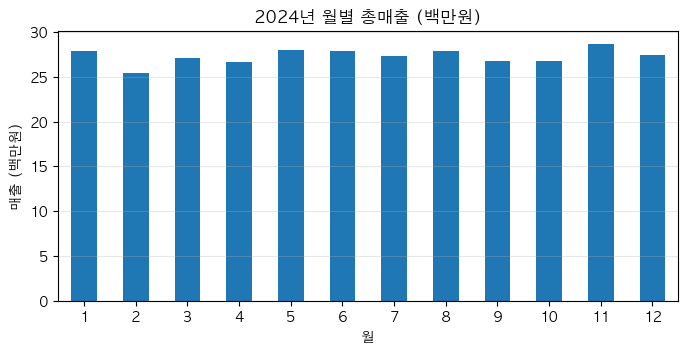

In [66]:
# 월별 총매출 추이 (간단한 시각화 맛보기, 자세한 시각화는 3회차)
monthly_total = sales.groupby("월")["매출액"].sum() / 1_000_000

plt.figure(figsize=(8, 3.5))
monthly_total.plot(kind="bar", color="tab:blue")
plt.title("2024년 월별 총매출 (백만원)")
plt.xlabel("월")
plt.ylabel("매출 (백만원)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [67]:
# 날짜 범위 필터링: 문자열 비교가 그대로 된다
q2 = sales[(sales["날짜"] >= "2024-04-01") & (sales["날짜"] <= "2024-06-30")]
print("2분기 행 수:", len(q2), "| 총매출:", f"{q2['매출액'].sum():,}")

# 연-월 단위 그룹: to_period
sales.groupby(sales["날짜"].dt.to_period("M"))["매출액"].sum().head(3)

2분기 행 수: 273 | 총매출: 82,533,000


날짜
2024-01    27918000
2024-02    25389000
2024-03    27060000
Freq: M, Name: 매출액, dtype: int64

### 📝 시험 출제 포인트 (2장)

- "`나이` 가 40 이상이고 `요금제` 가 `5G` 인 고객 수" → `len(df[(df["나이"] >= 40) & (df["요금제"] == "5G")])`
- "`월요금` 기준 내림차순 상위 10개" → `df.sort_values("월요금", ascending=False).head(10)` 또는 `nlargest`
- "`지역` 별 `월요금` 평균" → `df.groupby("지역")["월요금"].mean()`
- "불필요한 컬럼 `고객ID` 삭제" → `df = df.drop(columns=["고객ID"])` (또는 `axis=1`). **모델링 전 ID 컬럼 삭제** 는 거의 매번 출제됩니다.
- "두 데이터를 `요금제` 기준으로 결합" → `pd.merge(df1, df2, on="요금제", how="left")`
- "컬럼명 변경" → `df.rename(columns={...})`
- 파생 변수 생성 → `np.where`, `apply`, `map` 중 하나

### ⚠️ 자주 하는 실수 (2장)

- **`and` / `or` 사용**: pandas 조건은 `&` / `|` 이고, 각 조건에 **괄호** 를 씌워야 합니다. 안 씌우면 우선순위 때문에 에러(`ValueError: The truth value of a Series is ambiguous`)가 납니다.
- **`drop`, `rename`, `sort_values` 결과를 대입하지 않음**: 이 메서드들은 새 객체를 반환합니다. `df = df.drop(...)` 처럼 다시 대입하거나 `inplace=True` 를 씁니다. 둘 다 하면(`df = df.drop(..., inplace=True)`) `df` 가 `None` 이 됩니다.
- **`loc[0:3]` 과 `iloc[0:3]` 의 행 수가 다름**: `loc` 는 끝을 포함(4행), `iloc` 는 미포함(3행).
- **`groupby` 결과에서 컬럼을 못 찾음**: 그룹 키가 **인덱스** 로 가 있으므로 `reset_index()` 를 하거나 `as_index=False` 를 씁니다.
- **`merge` 후 행이 늘어남**: 오른쪽 표에 키가 중복이면 행이 곱해집니다. 결합 전 `right["key"].is_unique` 를 확인합니다.
- **`SettingWithCopyWarning`**: 필터링한 결과에 바로 값을 대입할 때 발생. `sub = df[cond].copy()` 로 복사본을 만든 뒤 수정합니다.

---
## 3. 종합 실습

`data/customers.csv` 를 다시 읽어 시작합니다. 각 문제의 빈 셀에 코드를 작성하세요. 정답은 접힌 영역에 있습니다.

In [68]:
df = pd.read_csv(f"{DATA_DIR}/customers.csv", dtype={"우편번호": str}, parse_dates=["가입일"])
sales = pd.read_csv(f"{DATA_DIR}/sales_2024.csv", parse_dates=["날짜"])
plans = pd.read_excel(f"{DATA_DIR}/customers.xlsx", sheet_name="plans")
print(df.shape, sales.shape, plans.shape)

(300, 11) (1098, 4) (3, 3)


### 문제 1. 구조 파악

`df` 의 행·열 개수, 컬럼별 결측치 개수, `이탈여부` 의 값별 비율을 각각 출력하시오.

In [69]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
print(df.shape)
print(df.isnull().sum())
print(df["이탈여부"].value_counts(normalize=True))
```

</details>

### 문제 2. 조건 필터링

`지역` 이 `"서울"` 또는 `"경기"` 이고, `데이터사용량` 이 30 이상인 고객을 `q2` 에 저장하고 행 수를 출력하시오.

In [70]:
# 여기에 코드를 작성하세요
q2 = None

<details>
<summary>정답 보기</summary>

```python
q2 = df[df["지역"].isin(["서울", "경기"]) & (df["데이터사용량"] >= 30)]
print(len(q2))
```

</details>

### 문제 3. 정렬과 선택

`가입개월수` 가 가장 긴 고객 5명의 `고객ID`, `가입개월수`, `월요금` 을 출력하시오. (인덱스는 0부터 다시 매길 것)

In [71]:
# 여기에 코드를 작성하세요
q3 = None

<details>
<summary>정답 보기</summary>

```python
q3 = (
  df.sort_values("가입개월수", ascending=False)
    .head(5)[["고객ID", "가입개월수", "월요금"]]
    .reset_index(drop=True)
)
q3
```

</details>

### 문제 4. 파생 변수

`나이` 를 기준으로 `연령대` 컬럼을 만드시오. 30 미만 `"20대이하"`, 30 이상 50 미만 `"30-40대"`, 50 이상 `"50대이상"`, 결측은 `"미상"`. 그리고 `연령대` 별 고객 수를 출력하시오.

> **힌트**: `np.select` 를 쓰고, 결측 조건을 **가장 먼저** 두어야 `NaN` 비교(항상 False) 문제를 피할 수 있다.

In [72]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
conditions = [
  df["나이"].isna(),
  df["나이"] < 30,
  df["나이"] < 50,
]
labels = ["미상", "20대이하", "30-40대"]
df["연령대"] = np.select(conditions, labels, default="50대이상")
print(df["연령대"].value_counts())
```

</details>

### 문제 5. 그룹 집계

`요금제` 별로 고객 수, 평균 `월요금`, 이탈률(`이탈여부 == "Yes"` 비율)을 구해 `q5` 에 저장하시오. 컬럼명은 `고객수`, `평균요금`, `이탈률` 으로 하고, 이탈률 내림차순으로 정렬하시오.

In [73]:
# 여기에 코드를 작성하세요
q5 = None

<details>
<summary>정답 보기</summary>

```python
q5 = (
  df.groupby("요금제")
    .agg(
      고객수=("고객ID", "count"),
      평균요금=("월요금", "mean"),
      이탈률=("이탈여부", lambda s: (s == "Yes").mean()),
    )
    .sort_values("이탈률", ascending=False)
)
q5
```

</details>

### 문제 6. 결합

`df` 와 `plans` 를 `요금제` 기준으로 왼쪽 결합(left join)하여 `q6` 에 저장하고, `속도Mbps` 별 평균 `데이터사용량` 을 출력하시오.

In [74]:
# 여기에 코드를 작성하세요
q6 = None

<details>
<summary>정답 보기</summary>

```python
q6 = pd.merge(df, plans, on="요금제", how="left")
print(q6.groupby("속도Mbps")["데이터사용량"].mean().round(2))
```

</details>

### 문제 7. 날짜 집계

`sales` 에서 **분기별(quarter) · 매장별** 매출(`매출액`) 합계를 pivot_table 로 만들어 `q7` 에 저장하고 출력하시오. 행은 분기, 열은 매장.

In [75]:
# 여기에 코드를 작성하세요
q7 = None

<details>
<summary>정답 보기</summary>

```python
sales["분기"] = sales["날짜"].dt.quarter
q7 = pd.pivot_table(sales, index="분기", columns="매장", values="매출액", aggfunc="sum")
q7
```

</details>

### 문제 8. 모델링 준비 (5회차 예습)

`df` 에서 `고객ID`, `우편번호`, `가입일` 컬럼을 삭제하고, `이탈여부` 를 `y`, 나머지를 `X` 로 분리하시오. `X.shape`, `y.shape` 를 출력하시오.

In [76]:
# 여기에 코드를 작성하세요
X, y = None, None

<details>
<summary>정답 보기</summary>

```python
df_model = df.drop(columns=["고객ID", "우편번호", "가입일"])
y = df_model["이탈여부"]
X = df_model.drop(columns=["이탈여부"])
print(X.shape, y.shape)
```

</details>

---
## 4. 오늘의 정리

### 핵심 요약

| 주제 | 기억할 것 |
|------|-----------|
| 구조 확인 루틴 | `head` → `shape` → `info` → `describe` → `value_counts` → `isnull().sum()` |
| 속성 vs 메서드 | `shape`, `columns`, `dtypes` 는 괄호 없음. `head()`, `info()`, `describe()` 는 괄호 있음 |
| 컬럼 선택 | `df["c"]` 는 Series, `df[["c"]]` 는 DataFrame |
| `loc` / `iloc` | 이름 / 위치. `loc` 슬라이스는 끝 포함 |
| 조건 필터링 | `&`, `\|`, `~` + 괄호. `isin`, `between`, `str.contains`, `isna`. `query` 의 한글 컬럼은 백틱 |
| 파생 변수 | `np.where`(2갈래), `np.select`(여러 갈래), `map`(사전), `apply`(함수) |
| 수정 결과 대입 | `drop`, `rename`, `sort_values` 는 새 객체 반환 → `df = df.xxx(...)` |
| `groupby` | `groupby(키)[값].통계`, `agg`, named aggregation, `reset_index` |
| 결합 | `merge(on, how)` 는 키 기준, `concat(axis)` 는 이어 붙이기 |
| 날짜 | `.dt.year/month/dayofweek`, `to_period("M")` |

### 자기 점검 체크리스트

- [ ] 처음 보는 CSV 를 5분 안에 크기·타입·결측·분포까지 파악할 수 있다.
- [ ] `loc[0:3]` 과 `iloc[0:3]` 의 행 수 차이를 설명할 수 있다.
- [ ] 두 조건 이상을 `&`, `|` 로 결합해 필터링할 수 있다.
- [ ] `np.where` 와 `np.select` 로 조건 파생 변수를 만들 수 있다.
- [ ] `groupby().agg()` 로 그룹별 여러 통계를 한 표로 만들 수 있다.
- [ ] `merge` 의 `how` 네 가지 차이를 행 수로 설명할 수 있다.
- [ ] 날짜 컬럼에서 월을 꺼내 월별 합계를 낼 수 있다.

### 다음 회차 예고 — 3회차: 데이터 이해하기 (EDA)

- 한 변수의 분포 보기: 히스토그램, 박스플롯, `countplot`
- 두 변수의 관계 보기: 산점도, 상관계수(`corr`), `heatmap`
- 타깃(`이탈여부`)과 각 변수의 관계를 그림으로 확인하고 가설 세우기
- `matplotlib` 와 `seaborn` 의 역할 분담, 시험에 나오는 그래프 유형